# QRecauda: tablas del pitch

Todo sale de `registro/corridas/*.json` y `registro/veredictos.jsonl` mediante `qrecauda.presentacion.figuras` (con su test). Este cuaderno no calcula nada.

Reproducir: `uv sync --frozen --extra informe --group dev` y `.venv/bin/jupyter nbconvert --to notebook --execute --inplace notebooks/qrecauda.ipynb`.

In [1]:
from IPython.display import Image, Markdown, display

from qrecauda.presentacion import figuras as f

RAIZ = f.localizar_raiz()


def ver(tabla):
    display(Markdown(f.a_markdown(tabla)))


def mostrar(fig):
    display(Image(data=f.a_png(fig)))

## Veredictos
E1 y E2 cumplen; E3 no cumple.

In [2]:
ver(f.tabla_veredictos(RAIZ))

| eureka | corrida | desenlace | criterios_decisivos | criterios_que_fallan | resumen | commit |
|---|---|---|---|---|---|---|
| E1 | C.E1 | CUMPLE | 18 | 0 | el pipeline entrega claves que pasan M1–M5 con entrada ruidosa; esto no certifica origen cuántico. Hallazgo R.00-1 (no decide): la clave de C.E1b pasa M1–M5 en 3/3 semillas. | a991216a |
| E2 | C.E2 | CUMPLE | 9 | 0 | K1–K4 en todas las celdas sintéticas | 26e5b41d |
| E3 | C.E3 | NO_CUMPLE | 6 | 3 | no cumple: T2/20261007, T2/20261008, T2/20261009 | 41cd0589 |

## E1: clave por sub-corrida y semilla

In [3]:
ver(f.tabla_e1(RAIZ))

| corrida | semilla | origen | M1_sesgo | M3_p | M4_p | M5_p | h_min_salida | bits_clave | pasa_M1_M5 |
|---|---|---|---|---|---|---|---|---|---|
| C.E1a | 20261007 | prng_clasico | 0.0003606 | 0.4806 | 0.1057 | 0.8982 | 0.9952 | 956832 | sí |
| C.E1a | 20261008 | prng_clasico | 5.117e-05 | 0.9202 | 0.2769 | 0.9069 | 0.9961 | 957578 | sí |
| C.E1a | 20261009 | prng_clasico | 0.0001518 | 0.7663 | 0.9064 | 0.8925 | 0.9958 | 958257 | sí |
| C.E1b | 20261007 | simulador_aer | 0.0007107 | 0.1647 | 0.5447 | 0.6102 | 0.9942 | 955434 | sí |
| C.E1b | 20261008 | simulador_aer | 0.0002765 | 0.5889 | 0.6976 | 0.2782 | 0.9954 | 954718 | sí |
| C.E1b | 20261009 | simulador_aer | 0.0003532 | 0.4902 | 0.02607 | 0.9579 | 0.9952 | 954102 | sí |
| C.E1c | 20261007 | simulador_aer | 2.247e-05 | 0.9649 | 0.8773 | 0.5219 | 0.9961 | 956905 | sí |
| C.E1c | 20261008 | simulador_aer | 0.0005269 | 0.3027 | 0.0966 | 0.1836 | 0.9947 | 956560 | sí |
| C.E1c | 20261009 | simulador_aer | 0.000161 | 0.7528 | 0.2176 | 0.59 | 0.9957 | 956570 | sí |

### Fuentes de control (E1d)

| fuente | semillas | bits | h_90b_media | mcv_media |
|---|---|---|---|---|
| ideal | 3 | 1000000 | 0.8518 | 0.9954 |
| markov | 3 | 1000000 | 0.1705 | 0.9929 |
| periodica | 3 | 1000000 | 0 | 0.9963 |
| sesgada | 3 | 1000000 | 0.3222 | 0.5124 |

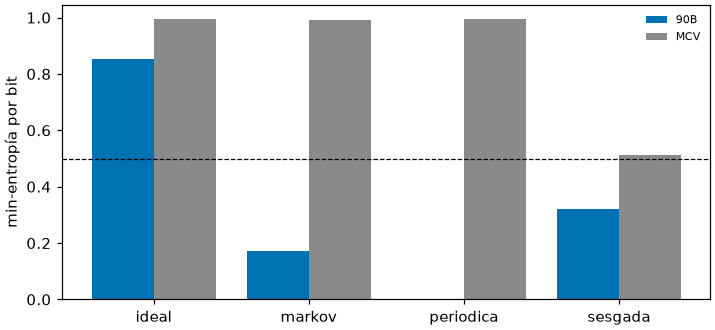

In [4]:
ver(f.tabla_e1_fuentes(RAIZ))
mostrar(f.fig_e1_fuentes(RAIZ))

## E2: sesgo crudo y residual por nivel de ruido y técnica

| nivel | tecnica | semillas | sesgo_crudo | sesgo_residual | ic95_inf | ic95_sup | factor |
|---|---|---|---|---|---|---|---|
| alto | mthree | 3 | 0.04988 | 0.001259 | 0.001259 | 0.001259 | 39.63 |
| alto | ninguna | 3 | 0.04988 | 0.04988 | 0.04934 | 0.05043 | 1 |
| alto | twirling_propio | 3 | 0.04988 | 0.00114 | 0.0008537 | 0.001771 | 43.74 |
| bajo | mthree | 3 | 0.01002 | 0.0005677 | 0.0005677 | 0.0005677 | 17.66 |
| bajo | ninguna | 3 | 0.01002 | 0.01002 | 0.009477 | 0.01057 | 1 |
| bajo | twirling_propio | 3 | 0.01002 | 0.0008258 | 0.0006158 | 0.001479 | 12.14 |
| medio | mthree | 3 | 0.02997 | 0.0007609 | 0.0007609 | 0.0007609 | 39.39 |
| medio | ninguna | 3 | 0.02997 | 0.02997 | 0.02942 | 0.03051 | 1 |
| medio | pec | 3 | 0.02997 | 0.03001 | 0.03001 | 0.03001 | 0.9986 |
| medio | twirling_propio | 3 | 0.02997 | 0.0009209 | 0.0007245 | 0.001601 | 32.54 |
| medio | zne | 3 | 0.02997 | 0.03092 | 0.03092 | 0.03092 | 0.9692 |
| realista | mthree | 3 | 0.0008425 | 0.0009718 | 0.0009718 | 0.0009718 | 0.8669 |
| realista | ninguna | 3 | 0.0007626 | 0.0007626 | 0.0006152 | 0.001476 | 1 |
| realista | twirling_propio | 3 | 0.0007626 | 0.0005757 | 0.0004762 | 0.001288 | 1.325 |
| simetrico | twirling_propio | 3 | 0.0005201 | 0.0007869 | 0.0005847 | 0.00144 | 0.661 |
| sin_ruido | twirling_propio | 3 | 0.0006243 | 0.0008385 | 0.0006174 | 0.001482 | 0.7445 |

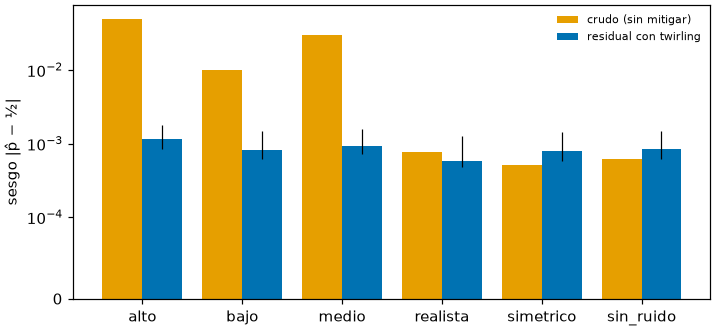

In [5]:
ver(f.tabla_e2(RAIZ))
mostrar(f.fig_e2_sesgo(RAIZ))

## E3: tasa (M6) y latencia (M7), perfil A que decide

| semilla | M6_bps | M6_umbral_bps | M6_cumple | M7_p95_ms | M7_umbral_ms | M7_cumple | repeticiones |
|---|---|---|---|---|---|---|---|
| 20261007 | 1.874e+05 | 1e+04 | sí | 9378 | 499.9 | NO | 30 |
| 20261008 | 1.955e+05 | 9998 | sí | 5554 | 499.9 | NO | 30 |
| 20261009 | 1.805e+05 | 9998 | sí | 5547 | 500.2 | NO | 30 |

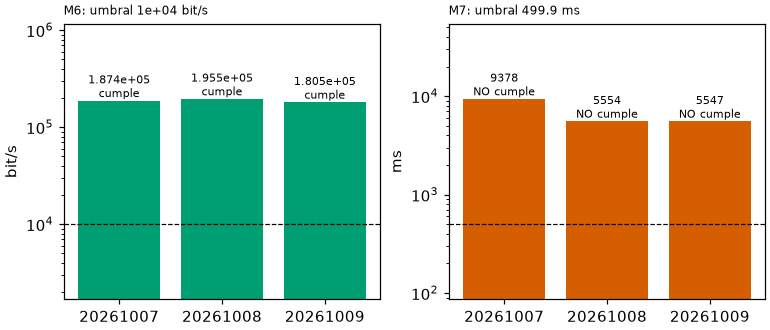

In [6]:
ver(f.tabla_e3(RAIZ))
mostrar(f.fig_e3_cuello(RAIZ))

### Perfil B (reserva de claves, no decide)

In [7]:
ver(f.tabla_perfil_b(RAIZ))

| semilla | tx_por_s | transacciones | ciclo_mediana_us | ciclo_p95_us | entropia_insuficiente | decide |
|---|---|---|---|---|---|---|
| 20261007 | 6.364e+04 | 1000 | 14.95 | 17.94 | NO | NO |
| 20261008 | 6.263e+04 | 1000 | 15.11 | 17.88 | NO | NO |
| 20261009 | 3.067e+04 | 1000 | 21.74 | 38.72 | NO | NO |